In [ ]:
import pandas as pd

file_path = "Iris.csv"
df = pd.read_csv(file_path)

# vemos las primeras 5 filas
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


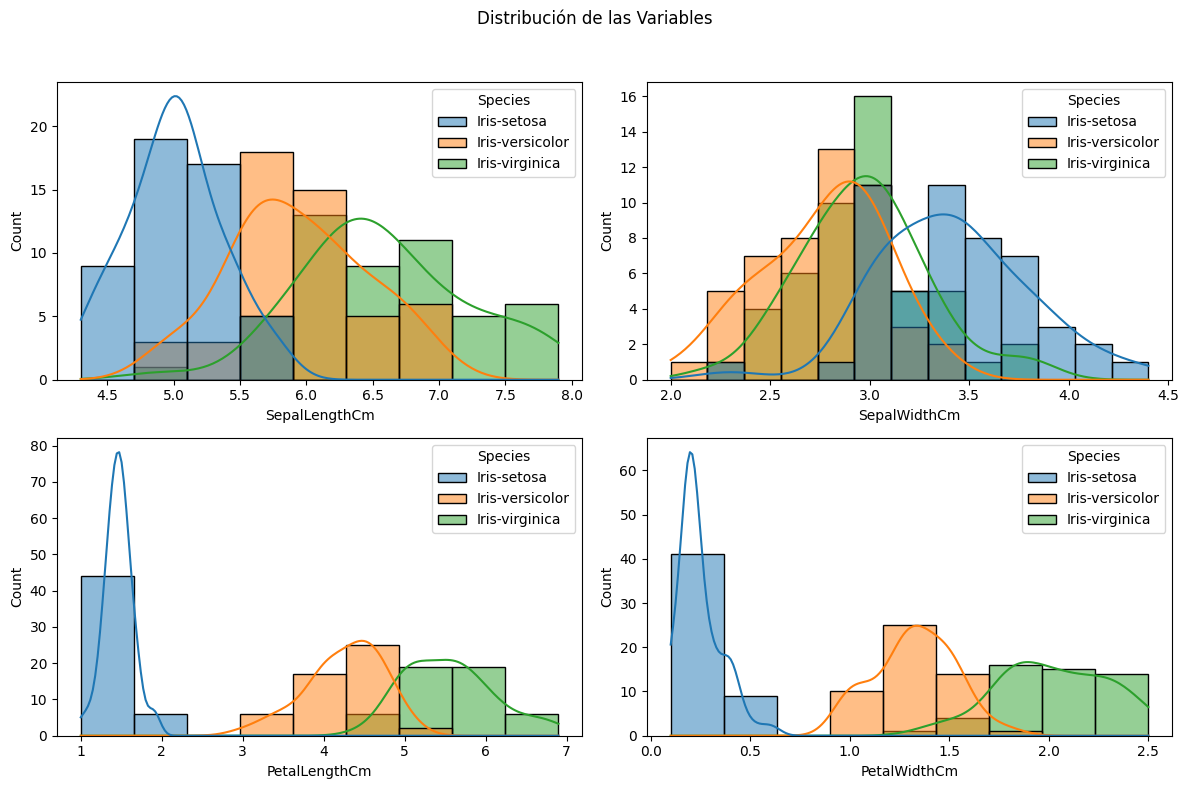

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# analizamos distribución de las variables

# creamos histogramas para las variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribución de las Variables")

sns.histplot(df, x="SepalLengthCm", hue="Species", kde=True, ax=axes[0, 0])
sns.histplot(df, x="SepalWidthCm", hue="Species", kde=True, ax=axes[0, 1])
sns.histplot(df, x="PetalLengthCm", hue="Species", kde=True, ax=axes[1, 0])
sns.histplot(df, x="PetalWidthCm", hue="Species", kde=True, ax=axes[1, 1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

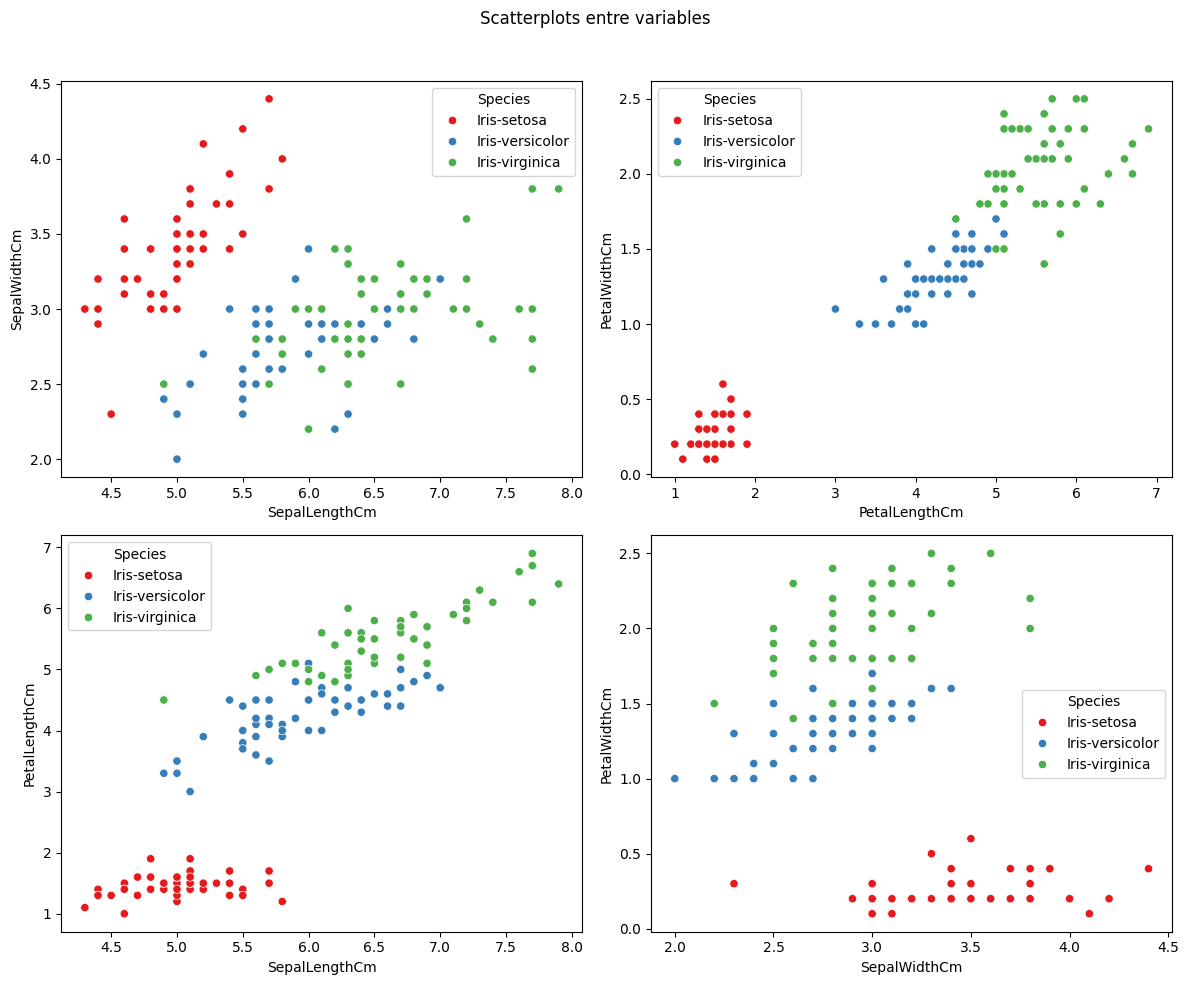

<ipython-input-20-ceb64ec1da35>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Species", y=var, ax=ax, palette="Set2")
<ipython-input-20-ceb64ec1da35>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Species", y=var, ax=ax, palette="Set2")
<ipython-input-20-ceb64ec1da35>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Species", y=var, ax=ax, palette="Set2")
<ipython-input-20-ceb64ec1da35>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

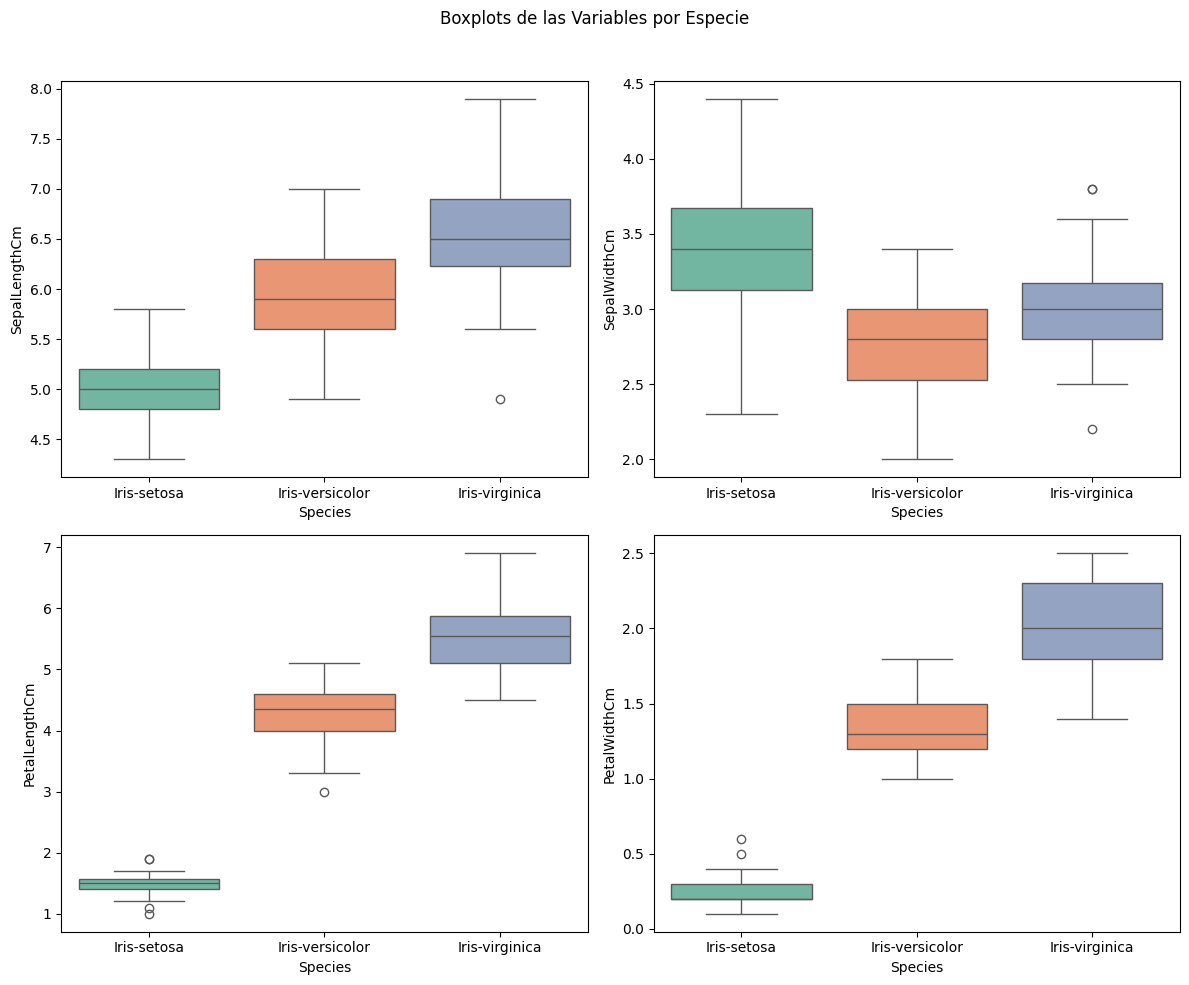

In [ ]:
# scatterplot para ver la relación entre variables
def plot_scatterplots(df):
    pair_vars = [("SepalLengthCm", "SepalWidthCm"),
                 ("PetalLengthCm", "PetalWidthCm"),
                 ("SepalLengthCm", "PetalLengthCm"),
                 ("SepalWidthCm", "PetalWidthCm")]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("Scatterplots entre variables")

    for (var_x, var_y), ax in zip(pair_vars, axes.flatten()):
        sns.scatterplot(data=df, x=var_x, y=var_y, hue="Species", ax=ax, palette="Set1")
        ax.set_xlabel(var_x)
        ax.set_ylabel(var_y)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# boxplot
def plot_boxplots(df):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("Boxplots de las Variables por Especie")

    variables = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

    for var, ax in zip(variables, axes.flatten()):
        sns.boxplot(data=df, x="Species", y=var, ax=ax, palette="Set2")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# graficamos funciones
plot_scatterplots(df)
plot_boxplots(df)


El mejor valor de k es 3 con una precisión de validación cruzada de 0.9583

Resultados de la validación cruzada:
   k  Cross Validation Accuracy
0  1                   0.950000
1  3                   0.958333
2  5                   0.941667
3  7                   0.941667
4  9                   0.933333


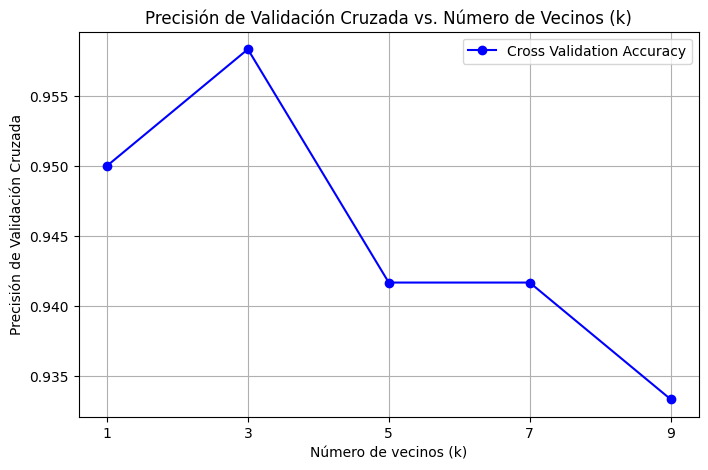

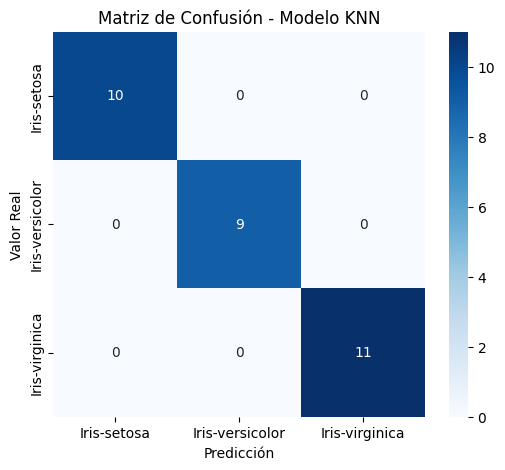

In [ ]:
# modelo KNN

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# eliminamos la columna id xq no es relevante para el modelo
df = df.drop(columns=['Id'])

# separamos la variable objetivo (y)
X = df.drop(columns=['Species'])
y = df['Species']

# encoder para las etiquetas de la variable objetivo (especie)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# dividimos  datos en conjunto de train y test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# definimos los valores de k que vamos a probar
k_values = [1, 3, 5, 7, 9]
cv_scores = []

# evaluamos el modelo con validación cruzada para cada valor de k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5) # con 5 folds
    cv_scores.append(np.mean(scores))

# creamos un DataFrame con los resultados
cv_results = pd.DataFrame({"k": k_values, "Cross Validation Accuracy": cv_scores})

# determinamos el mejor valor de k
best_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)

# mostramos el mejor k y su precisión
print(f"El mejor valor de k es {best_k} con una precisión de validación cruzada de {best_score:.4f}")

# mostramos los resultados en formato tabla
print("\nResultados de la validación cruzada:")
print(cv_results)

# visualizamos grafico con la precisión de validación cruzada para cada K
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross Validation Accuracy')
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Precisión de Validación Cruzada")
plt.title("Precisión de Validación Cruzada vs. Número de Vecinos (k)")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()

# entrenamos el modelo final con el mejor valor de k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# hacemos predicciones en el conjunto de prueba
y_pred = knn_final.predict(X_test)

# generamos la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# graficamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Modelo KNN")
plt.show()


Modelo 1 - Puntaje promedio de validación cruzada: 0.9417
Modelo 2 - Puntaje promedio de validación cruzada: 0.9500
Modelo 3 - Puntaje promedio de validación cruzada: 0.9500
Modelo 4 - Puntaje promedio de validación cruzada: 0.9500

El mejor modelo tiene un puntaje de validación cruzada de 0.9500
Precisión del modelo en el conjunto de prueba: 1.0000


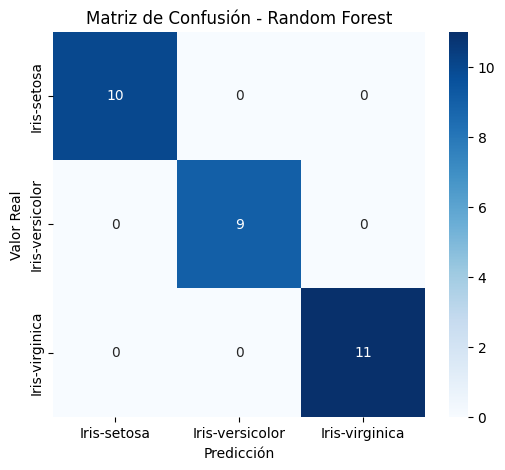

In [ ]:
# random forest con cv
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# separar las características y la variable objetivo
X = df.drop(columns=['Species'])
y = df['Species']

# encoder variable objetivo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# definimos hiperparámetros a probar
params = [
    {'n_estimators': 30, 'max_depth': 3, 'min_samples_split': 2},
    {'n_estimators': 50, 'max_depth': 4, 'min_samples_split': 3},
    {'n_estimators': 70, 'max_depth': 5, 'min_samples_split': 4},
    {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 5}
]

# entrenamos y hacemos cvq
best_score = 0
best_model = None

for i, param in enumerate(params):
    model = RandomForestClassifier(**param, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    avg_score = cv_scores.mean()
    print(f'Modelo {i+1} - Puntaje promedio de validación cruzada: {avg_score:.4f}')

    # guardamos el mejor modelo
    if avg_score > best_score:
        best_score = avg_score
        best_model = model

# entrenamos el mejor modelo con todo el conjunto de entrenamiento
best_model.fit(X_train, y_train)

# evaluamos el modelo en el conjunto de prueba
y_pred = best_model.predict(X_test)

# calculamos precisión en el conjunto de prueba
test_accuracy = accuracy_score(y_test, y_pred)

# mostramos el mejor modelo y su precisión
print(f"\nEl mejor modelo tiene un puntaje de validación cruzada de {best_score:.4f}")
print(f"Precisión del modelo en el conjunto de prueba: {test_accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)

# graficamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()
